# Fruit Classification CNN

In [49]:
import torch
import numpy as np

# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [50]:
# Organizing the classes correctly
import pandas as pd
folder_to_class = {}
test_df = pd.read_csv('Fruit_dataset/test.csv')
val_df = pd.read_csv('Fruit_dataset/val.csv')

val_classes = ['']
test_classes = ['']

for i in range(len(test_df)):
    folder_loc = test_df.iloc[i]['image:FILE'].split('/')[1]
    if not folder_loc: break
    if folder_loc != test_classes[-1]:
        test_classes.append(folder_loc)
        
for i in range(len(val_df)):
    folder_loc = val_df.iloc[i]['image:FILE'].split('/')[1]
    if folder_loc != val_classes[-1]:
        val_classes.append(folder_loc)

val_classes = val_classes[1:]
test_classes = test_classes[1:]
folder_to_class = dict(zip(val_classes, test_classes))

print(folder_to_class)


{'oil_palm': '28', 'hog_plum': '3', 'apricot': '93', 'sugar_apple': '58', 'rambutan': '80', 'yellow_plum': '49', 'pineapple': '43', 'dewberry': '71', 'plumcot': '23', 'ambarella': '8', 'grenadilla': '46', 'elderberry': '98', 'barbadine': '87', 'horned_melon': '39', 'chico': '61', 'mock_strawberry': '92', 'cashew': '44', 'finger_lime': '9', 'apple': '12', 'eggplant': '38', 'pawpaw': '0', 'chokeberry': '55', 'jamaica_cherry': '18', 'grapefruit': '88', 'santol': '86', 'chenet': '95', 'salak': '1', 'indian_strawberry': '16', 'cherimoya': '47', 'otaheite_apple': '7', 'dragonfruit': '15', 'raspberry': '27', 'mangosteen': '63', 'yali_pear': '60', 'taxus_baccata': '76', 'coconut': '19', 'guava': '41', 'black_mullberry': '83', 'durian': '73', 'ackee': '2', 'olive': '26', 'mandarine': '70', 'black_berry': '29', 'acerola': '32', 'jaboticaba': '24', 'fig': '82', 'langsat': '78', 'redcurrant': '77', 'gooseberry': '13', 'camu_camu': '11', 'barberry': '69', 'rose_hip': '67', 'jalapeno': '65', 'brazil

In [51]:
import os
# from PIL import Image

# root_dir = 'Fruit_dataset/train1'

# max_width, max_height = float(0), float(0)
# min_width, min_height = float('inf'), float('inf')

# for subdir, _, files in os.walk(root_dir):
#     for file in files:
#         if file.lower().endswith(('.png', '.jpg', '.jpeg')):
#             img_path = os.path.join(subdir, file)
#             with Image.open(img_path) as img:
#                 w, h = img.size
#                 if w > max_width:
#                     max_width = w
#                 if h > max_height:
#                     max_height = h
#                 if w < min_width:
#                     min_width = w
#                 if h < min_height:
#                     min_height = h

# print(f"Smallest width: {min_width}, Smallest height: {min_height}")
# print(f"Biggest width: {max_width}, Biggest height: {max_height}")
test_path = "./Fruit_dataset/test1"

# List all subfolders (classes)
class_folders = [name for name in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, name))]

print(f"Number of classes: {len(class_folders)}")

Number of classes: 100


In [52]:
from torchvision import datasets, transforms

from torchvision.datasets import ImageFolder

class MappedImageFolder(ImageFolder):
    def __init__(self, root, correct_order, transform=None):
        super().__init__(root, transform=transform)
        self.folder_to_label = {folder: correct_order.index(folder) for folder in self.classes}
        
    def __getitem__(self, index):
        path, _ = self.samples[index]
        image = self.loader(path)
        if self.transform is not None:
            image = self.transform(image)
        
        folder_name = path.split(os.sep)[-2]
        label = self.folder_to_label[folder_name]
        
        return image, label

batch_size = 32

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    # transforms.Pad(10),
    # transforms.CenterCrop((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # transforms.Pad(10),
    # transforms.CenterCrop((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

# train_data = datasets.ImageFolder(root='Fruit_dataset/train1', transform=train_transform)
train_data = MappedImageFolder('Fruit_dataset/train1', val_classes, transform=train_transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
folder_to_correct_label = {folder: val_classes.index(folder) for folder in train_data.classes}
print(train_loader.dataset.classes)
print(folder_to_correct_label)

# val_data = datasets.ImageFolder(root='Fruit_dataset/val1', transform=transform)
val_data = MappedImageFolder('Fruit_dataset/val1', val_classes, transform=transform)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True, pin_memory=True)
folder_to_correct_label = {folder: val_classes.index(folder) for folder in val_data.classes}
print(len(val_data))

# test_data = datasets.ImageFolder(root='Fruit_dataset/test1', transform=transform)
test_data = MappedImageFolder('Fruit_dataset/test1', test_classes, transform=transform)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True, pin_memory=True)
folder_to_correct_label = {folder: test_classes.index(folder) for folder in test_data.classes}
print(len(test_data))

# train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
# val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
# test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

['abiu', 'acai', 'acerola', 'ackee', 'ambarella', 'apple', 'apricot', 'avocado', 'banana', 'barbadine', 'barberry', 'betel_nut', 'bitter_gourd', 'black_berry', 'black_mullberry', 'brazil_nut', 'camu_camu', 'cashew', 'cempedak', 'chenet', 'cherimoya', 'chico', 'chokeberry', 'cluster_fig', 'coconut', 'corn_kernel', 'cranberry', 'cupuacu', 'custard_apple', 'damson', 'dewberry', 'dragonfruit', 'durian', 'eggplant', 'elderberry', 'emblic', 'feijoa', 'fig', 'finger_lime', 'gooseberry', 'goumi', 'grape', 'grapefruit', 'greengage', 'grenadilla', 'guava', 'hard_kiwi', 'hawthorn', 'hog_plum', 'horned_melon', 'indian_strawberry', 'jaboticaba', 'jackfruit', 'jalapeno', 'jamaica_cherry', 'jambul', 'jocote', 'jujube', 'kaffir_lime', 'kumquat', 'lablab', 'langsat', 'longan', 'mabolo', 'malay_apple', 'mandarine', 'mango', 'mangosteen', 'medlar', 'mock_strawberry', 'morinda', 'mountain_soursop', 'oil_palm', 'olive', 'otaheite_apple', 'papaya', 'passion_fruit', 'pawpaw', 'pea', 'pineapple', 'plumcot', '

In [53]:
import matplotlib.pyplot as plt

def imshow(img):
  img = img / 2 + 0.5
  plt.imshow(np.transpose(img, (1, 2, 0)))
  

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7938564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6073294].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6792717].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping inp

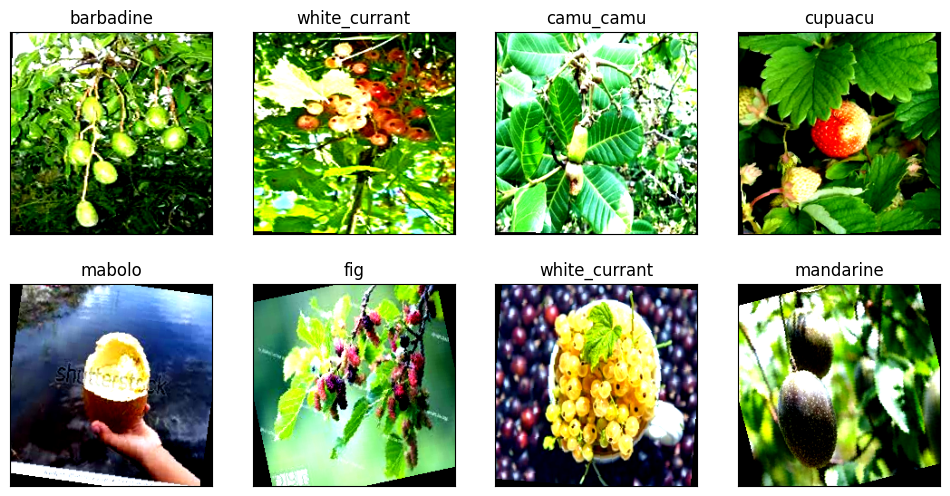

In [ ]:
classes = train_data.classes

dataiter = iter(train_loader)

images, labels = next(dataiter)
images = images.numpy() # convert images to numpy for display

images, labels = next(dataiter)

fig = plt.figure(figsize=(12, 6))
for idx in range(50):
  ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
  imshow(images[idx])
  ax.set_title(classes[labels[idx]])

# from PIL import Image
# import matplotlib.pyplot as plt
# import os

# # Get a list of image file paths
# image_paths = []
# for subdir, _, files in os.walk('Fruit_dataset/train1'):
#     for file in files:
#         if file.lower().endswith(('.png', '.jpg', '.jpeg')):
#             image_paths.append(os.path.join(subdir, file))

# # Display the first 8 images
# fig = plt.figure(figsize=(12, 6))
# for idx, img_path in enumerate(image_paths[:8]):
#     img = Image.open(img_path)
#     ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
#     plt.imshow(img)
#     ax.set_title(os.path.basename(os.path.dirname(img_path)))
# plt.show()

In [ ]:
# import torch.nn as nn
# import torch.nn.functional as F

# class Net(nn.Module):
#     def __init__(self):
#         super(Net, self).__init__()
#         self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
#         self.bn1 = nn.BatchNorm2d(32)

#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
#         self.bn2 = nn.BatchNorm2d(64)

#         # self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
#         # self.bn3 = nn.BatchNorm2d(64)

#         self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
#         self.bn3 = nn.BatchNorm2d(128)

#         # self.conv5 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
#         # self.bn5 = nn.BatchNorm2d(128)

#         # self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
#         # self.bn6 = nn.BatchNorm2d(128)

#         self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
#         self.bn4 = nn.BatchNorm2d(256)
        
#         # self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
#         # self.bn8 = nn.BatchNorm2d(256)

#         # self.conv9 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
#         # self.bn9 = nn.BatchNorm2d(256)

#         self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
#         self.bn5 = nn.BatchNorm2d(512)

#         # self.conv11 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
#         # self.bn11 = nn.BatchNorm2d(512)

#         # self.conv12 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
#         # self.bn12 = nn.BatchNorm2d(512)

#         # self.conv13 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
#         # self.bn13 = nn.BatchNorm2d(1024)

#         # self.conv14 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)
#         # self.bn14 = nn.BatchNorm2d(1024)

#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

#         self.fc1 = nn.Linear(512 * 14 * 14, 512)
#         self.fc2 = nn.Linear(512, 256)
#         self.fc3 = nn.Linear(256, 100)

#         self.dropout = nn.Dropout(0.2)

#     def forward(self, x):
#         x = self.bn1(F.relu(self.conv1(x)))

#         x = self.pool(x)
        
#         x = self.bn2(F.relu(self.conv2(x)))
#         # x = self.bn3(F.relu(self.conv3(x)))

#         x = self.pool(x)

#         x = self.bn3(F.relu(self.conv3(x)))
#         # x = self.bn5(F.relu(self.conv5(x)))
#         # x = self.bn6(F.relu(self.conv6(x)))

#         x = self.pool(x)

#         x = self.bn4(F.relu(self.conv4(x)))
#         # x = self.bn8(F.relu(self.conv8(x)))
#         # x = self.bn9(F.relu(self.conv9(x)))

#         x = self.pool(x)

#         x = self.bn5(F.relu(self.conv5(x)))
#         # x = self.bn11(F.relu(self.conv11(x)))
#         # x = self.bn12(F.relu(self.conv12(x)))

#         # x = self.pool(x)

#         # x = self.bn13(F.relu(self.conv13(x)))
#         # x = self.bn14(F.relu(self.conv14(x)))

#         # x = x.view(-1, 256 * 14 * 14)
#         x = x.view(x.size(0), -1)

#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         x = self.fc3(x)
#         return x
    
# model = Net()
# print(model)

# if(train_on_gpu):
#   model.cuda()

In [57]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        num_blocks = 4
        num_params = 64
        img_size = 224

        self.blocks = nn.ModuleList()

        for idx in range(num_blocks):
            if idx == 0:
                self.blocks.append(
                    nn.Conv2d(3, num_params, kernel_size=3, stride=1, padding=1)
                )
            else:
                num_params *= 2
                self.blocks.append(
                    nn.Conv2d(int(num_params / 2), num_params, kernel_size=3, stride=1, padding=1)
                )

            self.blocks.append(
                    nn.Conv2d(num_params, num_params, kernel_size=3, stride=1, padding=1)
            )
            self.blocks.append(nn.BatchNorm2d(num_params))
            self.blocks.append(nn.MaxPool2d(2, 2))
            img_size //= 2
            self.blocks.append(nn.ReLU())

        self.fc1 = nn.Linear(num_params * img_size * img_size, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, len(classes))

    def forward(self, x):
        for block in self.blocks:
            x = block(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x





model = Net()
print(model)

if(train_on_gpu):
  model.cuda()


Net(
  (blocks): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ReLU()
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): ReLU()
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): MaxPool2d(kernel_size=2, stride=2

In [58]:
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scaler = GradScaler()

C:\Users\trevo\AppData\Local\Temp\ipykernel_15192\1479397524.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [59]:
def calculate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Net(
  (blocks): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ReLU()
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): ReLU()
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): MaxPool2d(kernel_size=2, stride=2

In [ ]:
class EarlyStopping:
    def __init__(self, patience=1, min_delta=0.03):
        self.min_delta = min_delta
        self.patience = patience
        self.counter = 0
        self.min_val_loss = float('inf')

    def early_stopper(self, val_loss):
        if val_loss < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0
        elif val_loss > (self.min_val_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False
            

In [61]:
n_epochs = 50

valid_loss_min = np.inf

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

train_losses = []
val_losses = []

ealry_stopper = EarlyStopping(patience=3)

for epoch in range(1, n_epochs+1):
    train_loss = 0.0
    valid_loss = 0.0

    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * data.size(0)
        
    scheduler.step()

    current_lr = scheduler.get_last_lr()[0]
    print(f"Current LR: {current_lr:.6e}")
    train_acc = calculate_accuracy(model, train_loader, device)
    val_acc = calculate_accuracy(model, val_loader, device)
    print(f'Train Accuracy: {train_acc:.4f}, Val Accuracy: {val_acc:.4f}')


    model.eval()
    for batch_idx, (data, target) in enumerate(val_loader):
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()

        output = model(data)
        loss = criterion(output, target)

        valid_loss += loss.item() * data.size(0)

    train_loss = train_loss / len(train_loader.dataset)
    valid_loss = valid_loss / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(valid_loss)

    if ealry_stopper.early_stopper(valid_loss):
        print("Stopping Early...")
        break

    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch, train_loss, valid_loss))

    if valid_loss < valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
            valid_loss_min, valid_loss))
        torch.save(model.state_dict(), 'model.pt')
        valid_loss_min = valid_loss



CUDA is available!  Training on GPU ...
Current LR: 1.000000e-03
Train Accuracy: 0.0651, Val Accuracy: 0.0656
Epoch: 1 	Training Loss: 4.561834 	Validation Loss: 3.845761
Validation loss decreased (inf --> 3.845761).  Saving model ...
Current LR: 1.000000e-03
Train Accuracy: 0.0970, Val Accuracy: 0.0928
Epoch: 2 	Training Loss: 3.771658 	Validation Loss: 3.601554
Validation loss decreased (3.845761 --> 3.601554).  Saving model ...
Current LR: 1.000000e-03
Train Accuracy: 0.1060, Val Accuracy: 0.1076
Epoch: 3 	Training Loss: 3.628372 	Validation Loss: 3.557654
Validation loss decreased (3.601554 --> 3.557654).  Saving model ...
Current LR: 1.000000e-03
Train Accuracy: 0.1226, Val Accuracy: 0.1158
Epoch: 4 	Training Loss: 3.536663 	Validation Loss: 3.477312
Validation loss decreased (3.557654 --> 3.477312).  Saving model ...
Current LR: 1.000000e-03
Train Accuracy: 0.1375, Val Accuracy: 0.1342
Epoch: 5 	Training Loss: 3.443361 	Validation Loss: 3.406459
Validation loss decreased (3.47731

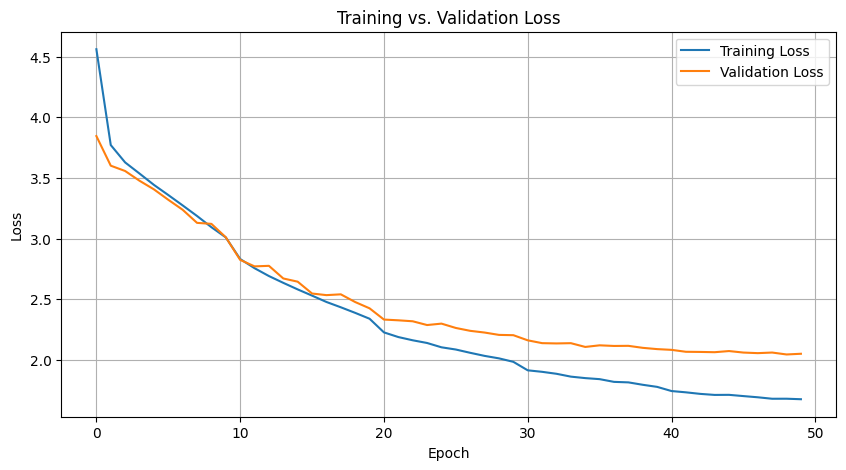

In [62]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [63]:
model.load_state_dict(torch.load('model.pt'))


<All keys matched successfully>

In [64]:
test_loss = 0.0
classes_correct = list(0. for i in range(100))
classes_total = list(0. for i in range(100))

model.eval()

classes = test_data.classes

for data, target in test_loader:
    if train_on_gpu:
        data, target = data.cuda(), target.cuda()

    output = model(data)
    loss = criterion(output, target)

    test_loss += loss.item() * data.size(0)

    _, pred = torch.max(output, 1)
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.cpu().numpy())

    for i in range(len(target)):
        label = target.data[i]
        classes_correct[label] += correct[i].item()
        classes_total[label] += 1

test_loss = test_loss / len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(100):
    if classes_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 100 * classes_correct[i] / classes_total[i],
            np.sum(classes_correct[i]), np.sum(classes_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(classes_correct) / np.sum(classes_total),
    np.sum(classes_correct), np.sum(classes_total)))

Test Loss: 2.051350

Test Accuracy of     0: 70% (35/50)
Test Accuracy of     1:  2% ( 1/50)
Test Accuracy of    10: 54% (27/50)
Test Accuracy of    11: 36% (18/50)
Test Accuracy of    12: 78% (39/50)
Test Accuracy of    13: 28% (14/50)
Test Accuracy of    14: 76% (38/50)
Test Accuracy of    15: 28% (14/50)
Test Accuracy of    16: 24% (12/50)
Test Accuracy of    17: 24% (12/50)
Test Accuracy of    18: 28% (14/50)
Test Accuracy of    19: 56% (28/50)
Test Accuracy of     2: 28% (14/50)
Test Accuracy of    20: 84% (42/50)
Test Accuracy of    21: 20% (10/50)
Test Accuracy of    22: 34% (17/50)
Test Accuracy of    23: 24% (12/50)
Test Accuracy of    24: 24% (12/50)
Test Accuracy of    25: 36% (18/50)
Test Accuracy of    26: 58% (29/50)
Test Accuracy of    27: 40% (20/50)
Test Accuracy of    28: 44% (22/50)
Test Accuracy of    29: 40% (20/50)
Test Accuracy of     3: 20% (10/50)
Test Accuracy of    30: 42% (21/50)
Test Accuracy of    31: 50% (25/50)
Test Accuracy of    32: 70% (35/50)
Test Ac

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5075778..1.7142857].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6442578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5178571..1.8112855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7142857].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47408962..1.7241396].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5161401..1.82

ValueError: num must be an integer with 1 <= num <= 8, not np.int64(9)

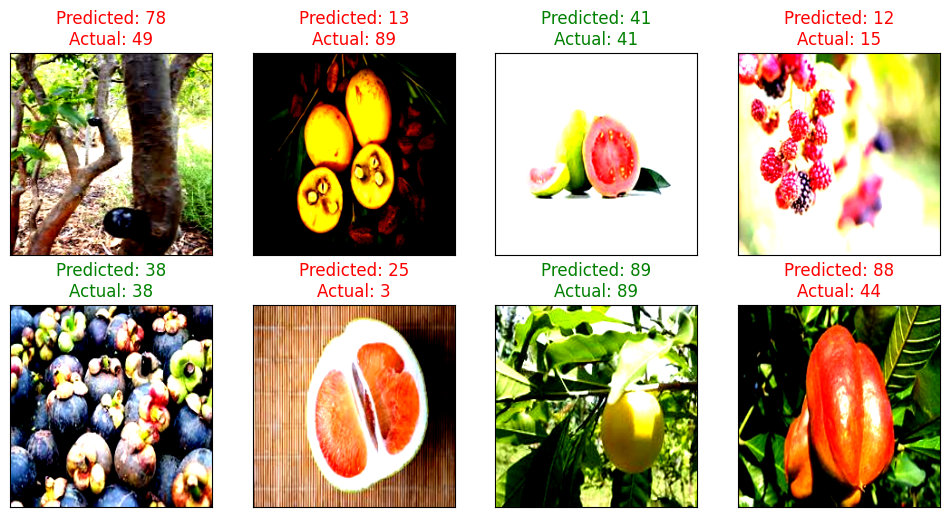

In [ ]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
# images = images.numpy()

if train_on_gpu:
    images = images.cuda()

output = model(images)
_, preds_tensor = torch.max(output, 1)
preds = preds_tensor.cpu().numpy()

fig = plt.figure(figsize=(12, 6))
for idx in np.arange(5):
    ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
    imshow(images[idx].cpu())
    ax.set_title(f'Predicted: {classes[preds[idx]]}\nActual: {classes[labels[idx]]}', color=('green' if preds[idx] == labels[idx] else 'red'))
    